In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [2]:
portfolio = {
    "NIFTYIETF.NS": 10,
    "HAL.NS": 2,
    "GOLDIETF.NS": 15,
    "ICICIBANK.NS": 5,
    "TATAPOWER.NS": 20,
    "TATAGOLD.NS": 50,
    "SILVERIETF.NS": 10,
}

tickers = list(portfolio.keys())

In [3]:
data = yf.download("HAL.NS", period="5d")
print(data)

C:\Users\Navneet\AppData\Local\Temp\ipykernel_25008\1784208210.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("HAL.NS", period="5d")
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open  Volume
Ticker           HAL.NS       HAL.NS       HAL.NS       HAL.NS  HAL.NS
Date                                                                  
2026-07-15  4420.500000  4486.600098  4414.600098  4444.399902  440343
2026-07-16  4433.799805  4460.000000  4394.000000  4420.500000  474213
2026-07-17  4500.700195  4509.399902  4426.799805  4435.899902  658032
2026-07-21  4474.299805  4508.600098  4461.399902  4485.000000  146528


In [4]:
raw_data = yf.download(tickers, period="1y")["Close"]
print(raw_data.head())
print(raw_data.shape)

C:\Users\Navneet\AppData\Local\Temp\ipykernel_25008\2746485922.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, period="1y")["Close"]
[*********************100%***********************]  7 of 7 completed


Ticker      GOLDIETF.NS       HAL.NS  ICICIBANK.NS  NIFTYIETF.NS  \
Date                                                               
2025-07-21    84.820000  4696.034668   1454.576416    280.959991   
2025-07-22    85.570000  4703.151367   1462.316650    280.640015   
2025-07-23    86.669998  4661.241699   1477.201782    282.079987   
2025-07-24    84.970001  4626.449219   1472.041626    280.679993   
2025-07-25    84.769997  4500.028809   1465.789795    278.619995   

Ticker      SILVERIETF.NS  TATAGOLD.NS  TATAPOWER.NS  
Date                                                  
2025-07-21     113.779999         9.65    399.375244  
2025-07-22     114.559998         9.71    396.691864  
2025-07-23     116.620003         9.82    400.021240  
2025-07-24     115.480003         9.67    398.232330  
2025-07-25     115.239998         9.63    392.915283  
(250, 7)


In [5]:
daily_returns = raw_data.pct_change().dropna()
print(daily_returns.head())

Ticker      GOLDIETF.NS    HAL.NS  ICICIBANK.NS  NIFTYIETF.NS  SILVERIETF.NS  \
Date                                                                           
2025-07-22     0.008842  0.001515      0.005321     -0.001139       0.006855   
2025-07-23     0.012855 -0.008911      0.010179      0.005131       0.017982   
2025-07-24    -0.019615 -0.007464     -0.003493     -0.004963      -0.009775   
2025-07-25    -0.002354 -0.027326     -0.004247     -0.007339      -0.002078   
2025-07-28    -0.001769 -0.010126      0.007650     -0.005922      -0.014752   

Ticker      TATAGOLD.NS  TATAPOWER.NS  
Date                                   
2025-07-22     0.006218     -0.006719  
2025-07-23     0.011328      0.008393  
2025-07-24    -0.015275     -0.004472  
2025-07-25    -0.004137     -0.013352  
2025-07-28    -0.001038      0.009738  


C:\Users\Navneet\AppData\Local\Temp\ipykernel_25008\239870902.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = raw_data.pct_change().dropna()


In [6]:
# latest price for each ticker 
latest_prices = raw_data.iloc[-1]

# Value of each holding = units own × latest price
holding_values = pd.Series({t: portfolio[t] * latest_prices[t] for t in tickers})

# Weight = what % of total portfolio each holding represents
weights = holding_values / holding_values.sum()
print(holding_values)
print(weights)

NIFTYIETF.NS     2738.800049
HAL.NS           8946.000000
GOLDIETF.NS      1830.000000
ICICIBANK.NS     7330.999756
TATAPOWER.NS     7632.000122
TATAGOLD.NS       692.000008
SILVERIETF.NS    2209.100037
dtype: float64
NIFTYIETF.NS     0.087282
HAL.NS           0.285096
GOLDIETF.NS      0.058319
ICICIBANK.NS     0.233628
TATAPOWER.NS     0.243221
TATAGOLD.NS      0.022053
SILVERIETF.NS    0.070401
dtype: float64


In [7]:
# --- Annualized volatility for each holding ---
annual_volatility = daily_returns.std() * np.sqrt(252)
print("Annual Volatility (individual holdings):")
print(annual_volatility.sort_values(ascending=False))

# --- Portfolio's combined daily return ---
portfolio_daily_returns = daily_returns.dot(weights)

# --- Portfolio annualized return and volatility ---
portfolio_annual_return = portfolio_daily_returns.mean() * 252
portfolio_annual_vol = portfolio_daily_returns.std() * np.sqrt(252)

print(f"\nPortfolio Annual Return: {portfolio_annual_return:.2%}")
print(f"Portfolio Annual Volatility: {portfolio_annual_vol:.2%}")

# --- Sharpe Ratio ---
risk_free_rate = 0.07
sharpe_ratio = (portfolio_annual_return - risk_free_rate) / portfolio_annual_vol
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Annual Volatility (individual holdings):
Ticker
SILVERIETF.NS    0.577447
GOLDIETF.NS      0.324324
TATAGOLD.NS      0.320752
HAL.NS           0.269269
TATAPOWER.NS     0.207563
ICICIBANK.NS     0.186389
NIFTYIETF.NS     0.125367
dtype: float64

Portfolio Annual Return: 8.79%
Portfolio Annual Volatility: 16.56%
Sharpe Ratio: 0.11


In [8]:
# --- Value at Risk (VaR) ---
confidence_level = 0.05
portfolio_value = holding_values.sum()

VaR_percent = np.percentile(portfolio_daily_returns, confidence_level * 100)
VaR_rupees = VaR_percent * portfolio_value

print(f"Portfolio Value: Rs {portfolio_value:,.2f}")
print(f"1-Day VaR (95% confidence): {VaR_percent:.2%}")
print(f"This means: on the worst 5% of days, you could lose more than Rs {abs(VaR_rupees):,.2f} in a single day")

# --- Correlation Matrix ---
correlation_matrix = daily_returns.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix.round(2))

Portfolio Value: Rs 31,378.90
1-Day VaR (95% confidence): -1.53%
This means: on the worst 5% of days, you could lose more than Rs 478.89 in a single day

Correlation Matrix:
Ticker         GOLDIETF.NS  HAL.NS  ICICIBANK.NS  NIFTYIETF.NS  SILVERIETF.NS  \
Ticker                                                                          
GOLDIETF.NS           1.00    0.20          0.24          0.29           0.86   
HAL.NS                0.20    1.00          0.23          0.51           0.23   
ICICIBANK.NS          0.24    0.23          1.00          0.64           0.27   
NIFTYIETF.NS          0.29    0.51          0.64          1.00           0.31   
SILVERIETF.NS         0.86    0.23          0.27          0.31           1.00   
TATAGOLD.NS           0.96    0.16          0.22          0.23           0.84   
TATAPOWER.NS          0.18    0.38          0.25          0.49           0.16   

Ticker         TATAGOLD.NS  TATAPOWER.NS  
Ticker                                    
GOLDIETF.N

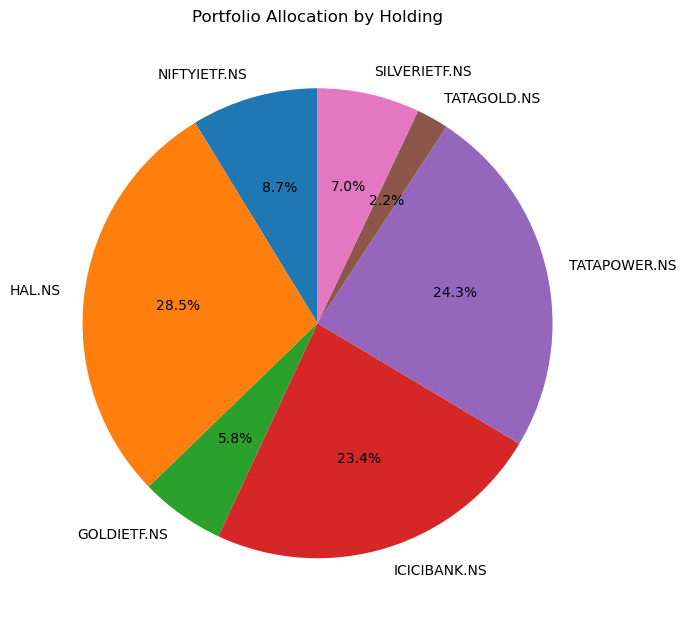

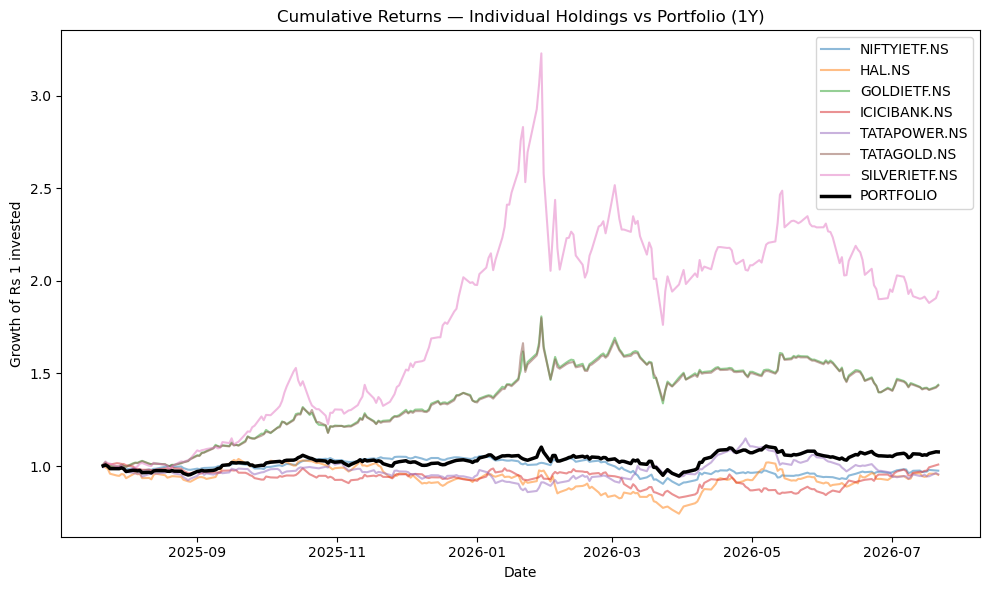

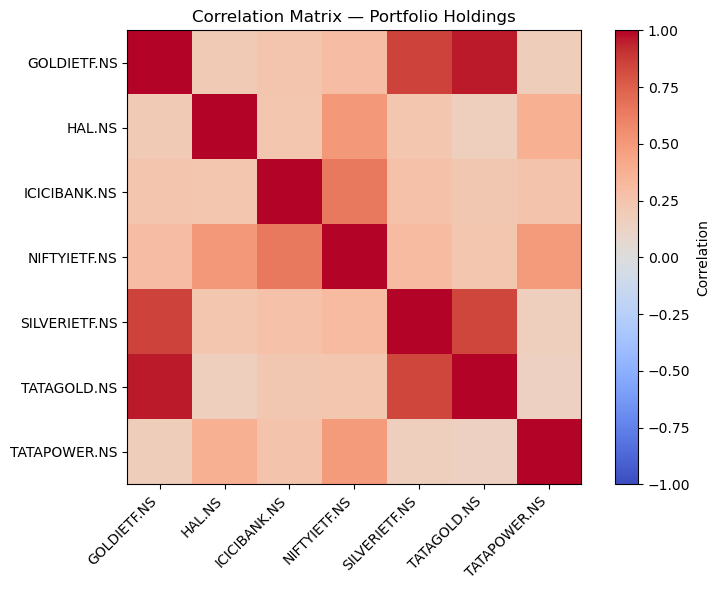

In [9]:
# --- Portfolio Allocation Pie Chart ---
plt.figure(figsize=(7, 7))
plt.pie(weights, labels=weights.index, autopct='%1.1f%%', startangle=90)
plt.title("Portfolio Allocation by Holding")
plt.tight_layout()
plt.savefig("portfolio_allocation.png", dpi=150)
plt.show()

# --- Cumulative Returns Over 1 Year ---
cumulative_returns = (1 + daily_returns).cumprod()
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()

plt.figure(figsize=(10, 6))
for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker, alpha=0.5)
plt.plot(portfolio_cumulative.index, portfolio_cumulative, label="PORTFOLIO", color="black", linewidth=2.5)
plt.title("Cumulative Returns — Individual Holdings vs Portfolio (1Y)")
plt.xlabel("Date")
plt.ylabel("Growth of Rs 1 invested")
plt.legend()
plt.tight_layout()
plt.savefig("cumulative_returns.png", dpi=150)
plt.show()

# --- Correlation Heatmap ---
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(tickers)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(tickers)), correlation_matrix.columns)
plt.title("Correlation Matrix — Portfolio Holdings")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()